In [21]:
# Steam Review Exploratory Data Analysis

This notebook explores 10,000 recent Steam reviews collected across five games and examines recommendation patterns, review length, playtime, language, engagement, and data quality.

SyntaxError: invalid syntax (921645350.py, line 3)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/steam_reviews.csv")

In [24]:
df["weighted_vote_score"] = pd.to_numeric(
    df["weighted_vote_score"],
    errors="coerce"
)

df["timestamp_created"] = pd.to_datetime(
    df["timestamp_created"],
    unit="s"
)

df["timestamp_updated"] = pd.to_datetime(
    df["timestamp_updated"],
    unit="s"
)

df["last_played"] = pd.to_datetime(
    df["last_played"],
    unit="s"
)

df["review_length"] = df["review"].str.len()

df["playtime_at_review_hours"] = (
    df["playtime_at_review"] / 60
)

In [ ]:
## 1. Dataset Overview

In [25]:
print("Shape:", df.shape)

print("\nReviews by game:")
print(df["game_name"].value_counts())

print("\nMissing values:")
print(df.isna().sum())

Shape: (10000, 27)

Reviews by game:
game_name
Warframe             2000
XCOM 2               2000
Against the Storm    2000
V Rising             2000
Marvel Rivals        2000
Name: count, dtype: int64

Missing values:
game_name                       0
app_id                          0
review_id                       0
steam_id                        0
num_games_owned                 0
num_reviews                     0
playtime_forever                0
playtime_last_two_weeks         0
playtime_at_review              0
last_played                     0
language                        0
review                         45
timestamp_created               0
timestamp_updated               0
voted_up                        0
votes_up                        0
votes_funny                     0
weighted_vote_score             0
comment_count                   0
steam_purchase                  0
received_for_free               0
written_during_early_access     0
primarily_steam_deck            

In [ ]:
### Dataset Overview

The dataset contains 10,000 recent Steam reviews across five games, with 2,000 reviews collected for each title.

Most fields are complete. The only missing values occur in the review text field, where 45 reviews have no usable text. As a result, the derived review length field also contains 45 missing values.

These records are retained for analyses involving non-text fields such as recommendation and playtime, but are excluded where review text is required.

In [ ]:
## 2. Recommendation Distribution

In [26]:
recommendation_counts = df["voted_up"].value_counts()

recommendation_pct = (
    df["voted_up"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

recommendation_by_game = pd.crosstab(
    df["game_name"],
    df["voted_up"],
    normalize="index"
).mul(100).round(2)

print("Overall recommendation distribution:")
print(recommendation_counts)

print("\nOverall recommendation percentage:")
print(recommendation_pct)

print("\nRecommendation percentage by game:")
print(recommendation_by_game)

Overall recommendation distribution:
voted_up
True     8372
False    1628
Name: count, dtype: int64

Overall recommendation percentage:
voted_up
True     83.72
False    16.28
Name: proportion, dtype: float64

Recommendation percentage by game:
voted_up           False  True 
game_name                      
Against the Storm  10.90  89.10
Marvel Rivals      34.45  65.55
V Rising           12.45  87.55
Warframe           10.15  89.85
XCOM 2             13.45  86.55


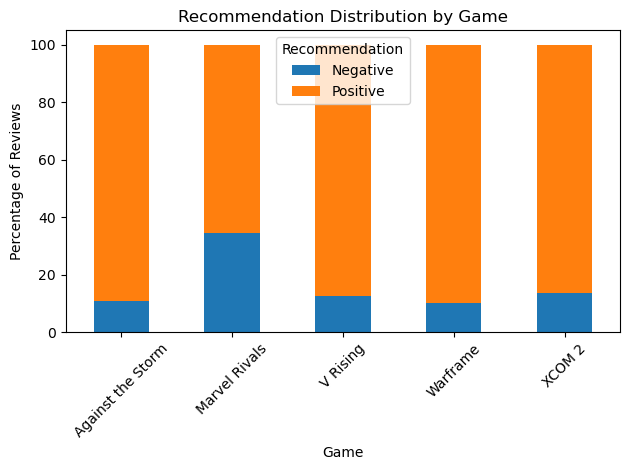

In [27]:
recommendation_by_game.plot(
    kind="bar",
    stacked=True
)

plt.title("Recommendation Distribution by Game")
plt.xlabel("Game")
plt.ylabel("Percentage of Reviews")
plt.legend(
    ["Negative", "Positive"],
    title="Recommendation"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Finding

Overall, 83.72% of reviews were positive and 16.28% were negative.

Recommendation patterns varied substantially across games. Marvel Rivals had the lowest positive recommendation rate at 65.55%, while the other four games had positive rates between approximately 86% and 90%.

This suggests that review sentiment is strongly game-specific rather than uniform across the dataset.

In [ ]:
## 3. Review Length Analysis

In [28]:
print("Review length summary:")
print(
    df["review_length"].describe()
)

print("\nReview length by recommendation:")
print(
    df.groupby("voted_up")["review_length"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("\nReview length by game:")
print(
    df.groupby("game_name")["review_length"]
    .agg(["count", "mean", "median"])
    .round(2)
)

Review length summary:
count    9955.000000
mean      200.132798
std       508.743594
min         1.000000
25%        13.000000
50%        48.000000
75%       164.000000
max      7999.000000
Name: review_length, dtype: float64

Review length by recommendation:
          count    mean  median
voted_up                       
False      1626  313.17    94.0
True       8329  178.07    42.0

Review length by game:
                   count    mean  median
game_name                               
Against the Storm   1998  296.37   102.0
Marvel Rivals       1998  111.09    29.0
V Rising            1982  259.40    64.0
Warframe            1990  142.81    28.0
XCOM 2              1987  191.18    54.0


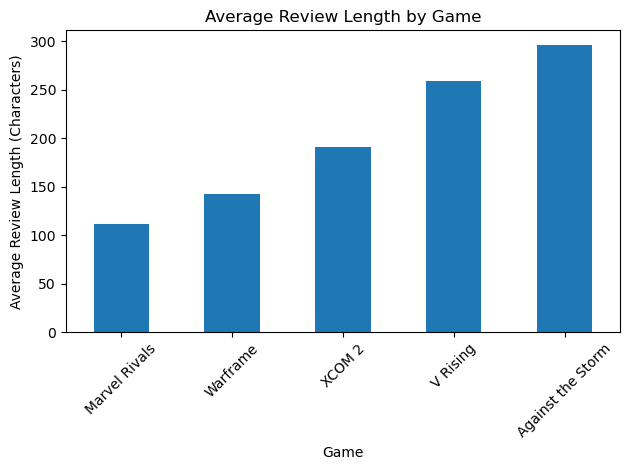

In [29]:
review_length_by_game = (
    df.groupby("game_name")["review_length"]
    .mean()
    .sort_values()
)

review_length_by_game.plot(
    kind="bar"
)

plt.title("Average Review Length by Game")
plt.xlabel("Game")
plt.ylabel("Average Review Length (Characters)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Finding

Review length varied substantially across games. Against the Storm had the longest reviews on average, while Marvel Rivals had the shortest.

Negative reviews were also substantially longer than positive reviews. The median negative review contained 94 characters, compared with 42 characters for positive reviews. Mean review length showed the same pattern, at 313.17 characters for negative reviews versus 178.07 for positive reviews.

This suggests that dissatisfied users tend to provide more detailed written feedback, while positive feedback is more often expressed briefly.

In [ ]:
## 4. Playtime Analysis

In [30]:
print("Playtime at review by recommendation:")
print(
    df.groupby("voted_up")["playtime_at_review_hours"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("\nPlaytime at review by game:")
print(
    df.groupby("game_name")["playtime_at_review_hours"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print("\nPlaytime by game and recommendation:")
print(
    df.groupby(
        ["game_name", "voted_up"]
    )["playtime_at_review_hours"]
    .agg(["count", "mean", "median"])
    .round(2)
)

Playtime at review by recommendation:
          count    mean  median
voted_up                       
False      1628  233.29   36.82
True       8372  219.24   60.60

Playtime at review by game:
                   count    mean  median
game_name                               
Against the Storm   2000   91.89   35.30
Marvel Rivals       2000  226.15   50.47
V Rising            2000   98.98   57.42
Warframe            2000  492.11  128.12
XCOM 2              2000  198.52   58.01

Playtime by game and recommendation:
                            count    mean  median
game_name         voted_up                       
Against the Storm False       218   27.30    8.71
                  True       1782   99.79   40.72
Marvel Rivals     False       689  314.52  116.50
                  True       1311  179.70   37.80
V Rising          False       249   51.97   26.85
                  True       1751  105.66   62.02
Warframe          False       203  625.00  100.62
                  True       1

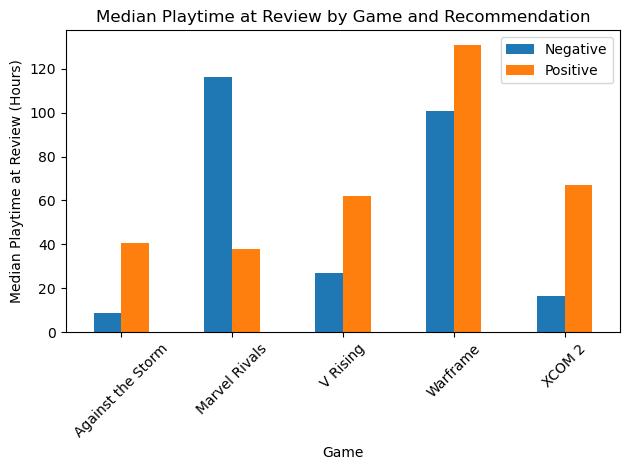

In [31]:
playtime_median = (
    df.groupby(
        ["game_name", "voted_up"]
    )["playtime_at_review_hours"]
    .median()
    .unstack()
)

playtime_median.columns = [
    "Negative",
    "Positive"
]

playtime_median.plot(
    kind="bar"
)

plt.title(
    "Median Playtime at Review by Game and Recommendation"
)

plt.xlabel("Game")
plt.ylabel("Median Playtime at Review (Hours)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Finding

Playtime patterns differed substantially across games.

In four of the five games, positive reviewers had higher median playtime than negative reviewers. Marvel Rivals showed the opposite pattern: negative reviewers had a median playtime of 116.5 hours, compared with 37.8 hours among positive reviewers.

This suggests that the relationship between player engagement and recommendation is game-specific rather than uniform across the dataset.

Playtime distributions were also strongly right-skewed, with mean playtime substantially higher than median playtime for several games. Median values are therefore more representative of typical player behavior.

In [ ]:
## 5. Language Distribution

In [32]:
print("Top languages overall:")

print(
    df["language"]
    .value_counts()
    .head(10)
)

print("\nTop language percentages overall:")

print(
    df["language"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .head(10)
)

top_5_languages = (
    df["language"]
    .value_counts()
    .head(5)
    .index
)

language_top5_by_game = (
    pd.crosstab(
        df["game_name"],
        df["language"],
        normalize="index"
    )
    .mul(100)
    .round(2)
    [top_5_languages]
)

print("\nTop 5 language percentages by game:")
print(language_top5_by_game.to_string())

Top languages overall:
language
english      5490
schinese      926
russian       887
spanish       535
brazilian     500
french        271
german        243
koreana       193
polish        164
turkish       141
Name: count, dtype: int64

Top language percentages overall:
language
english      54.90
schinese      9.26
russian       8.87
spanish       5.35
brazilian     5.00
french        2.71
german        2.43
koreana       1.93
polish        1.64
turkish       1.41
Name: proportion, dtype: float64

Top 5 language percentages by game:
language           english  schinese  russian  spanish  brazilian
game_name                                                        
Against the Storm    57.15     11.60     7.20     2.00       1.85
Marvel Rivals        67.50      3.10     4.20     7.40       5.55
V Rising             43.45      6.65    15.15     6.25       8.90
Warframe             52.25     15.50     8.40     5.35       5.75
XCOM 2               54.15      9.45     9.40     5.75       2

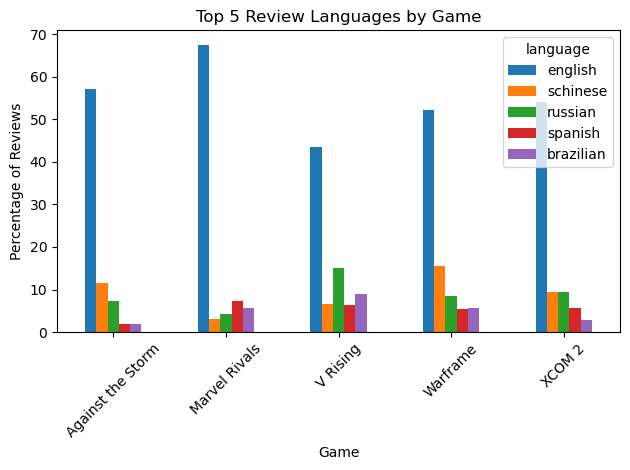

In [33]:
language_top5_by_game.plot(
    kind="bar"
)

plt.title("Top 5 Review Languages by Game")
plt.xlabel("Game")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [23]:
### Finding

English accounted for 54.9% of all reviews, but the dataset also contained substantial multilingual variation.

Language composition differed across games. Marvel Rivals had the highest share of English reviews at 67.5%, while V Rising had the lowest at 43.45% and showed a more diverse language mix.

Warframe had the highest share of Simplified Chinese reviews at 15.5%, while V Rising had a relatively high share of Russian and Brazilian Portuguese reviews.

These differences indicate that language composition is game-specific and should be considered in downstream text analysis.

SyntaxError: invalid syntax (2293423851.py, line 3)

In [ ]:
## 6. Timestamp Coverage

In [34]:
print("Overall timestamp coverage:")

print(
    "Earliest review:",
    df["timestamp_created"].min()
)

print(
    "Latest review:",
    df["timestamp_created"].max()
)

print("\nTimestamp coverage by game:")

timestamp_by_game = (
    df.groupby("game_name")["timestamp_created"]
    .agg(["min", "max"])
)

print(timestamp_by_game)

Overall timestamp coverage:
Earliest review: 2026-03-05 07:28:08
Latest review: 2026-08-18 16:35:16

Timestamp coverage by game:
                                  min                 max
game_name                                                
Against the Storm 2026-03-05 07:28:08 2026-08-18 15:34:11
Marvel Rivals     2026-08-12 04:11:07 2026-08-18 16:35:16
V Rising          2026-06-13 07:11:31 2026-08-18 16:10:07
Warframe          2026-08-03 08:00:10 2026-08-18 16:12:45
XCOM 2            2026-04-08 15:03:35 2026-08-18 16:17:20


In [35]:
df["review_month"] = (
    df["timestamp_created"]
    .dt.to_period("M")
    .astype(str)
)

reviews_by_month = (
    df.groupby(
        ["review_month", "game_name"]
    )
    .size()
    .unstack(fill_value=0)
)

print(reviews_by_month)

game_name     Against the Storm  Marvel Rivals  V Rising  Warframe  XCOM 2
review_month                                                              
2026-03                     284              0         0         0       0
2026-04                     303              0         0         0     340
2026-05                     255              0         0         0     535
2026-06                     248              0       477         0     375
2026-07                     735              0      1060         0     485
2026-08                     175           2000       463      2000     265


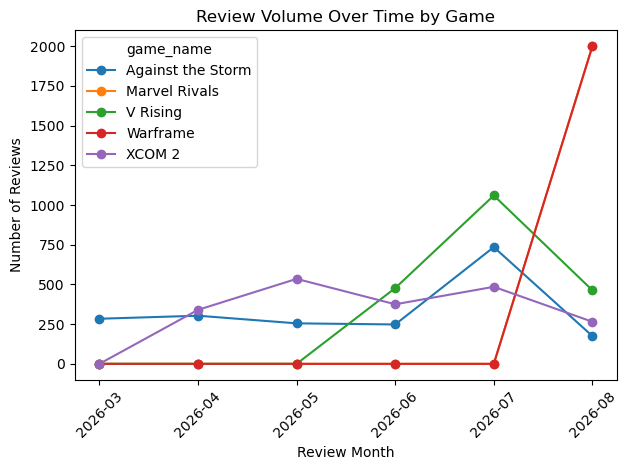

In [36]:
reviews_by_month.plot(
    kind="line",
    marker="o"
)

plt.title("Review Volume Over Time by Game")
plt.xlabel("Review Month")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
### Finding

The full dataset spans from March 5, 2026 to August 18, 2026, but timestamp coverage varies substantially across games.

Against the Storm covers the longest period, from March to August 2026, while Marvel Rivals covers only several days in August. Warframe also has a relatively short collection window.

This difference is caused by the sampling strategy: the dataset contains the 2,000 most recent reviews for each game. Games with higher review activity therefore reach 2,000 reviews within a shorter time window.

The dataset should therefore be interpreted as a cross-game sample of recent Steam reviews rather than a uniform historical sample.

In [ ]:
## 7. Helpful Votes and Review Engagement

In [37]:
print("Helpful votes summary:")
print(
    df["votes_up"].describe()
)

print("\nHelpful votes by game:")
print(
    df.groupby("game_name")["votes_up"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

print("\nPercentage of reviews with at least one helpful vote:")
print(
    df.assign(
        has_helpful_vote=df["votes_up"] > 0
    )
    .groupby("game_name")["has_helpful_vote"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nHelpful votes by recommendation:")
print(
    df.groupby("voted_up")["votes_up"]
    .agg(["count", "mean", "median", "max"])
    .round(2)
)

Helpful votes summary:
count    10000.000000
mean         0.605600
std          8.531654
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        784.000000
Name: votes_up, dtype: float64

Helpful votes by game:
                   count  mean  median  max
game_name                                  
Against the Storm   2000  1.20     0.0  174
Marvel Rivals       2000  0.29     0.0   23
V Rising            2000  0.92     0.0  784
Warframe            2000  0.16     0.0   14
XCOM 2              2000  0.46     0.0   31

Percentage of reviews with at least one helpful vote:
game_name
Against the Storm    27.30
Marvel Rivals        18.05
V Rising             18.60
Warframe              9.10
XCOM 2               19.30
Name: has_helpful_vote, dtype: float64

Helpful votes by recommendation:
          count  mean  median  max
voted_up                          
False      1628  1.70     0.0  784
True       8372  0.39     0.0  174


In [38]:
print("Review length vs helpful votes correlation:")

print(
    df[["review_length", "votes_up"]]
    .corr()
    .round(3)
)

Review length vs helpful votes correlation:
               review_length  votes_up
review_length          1.000     0.086
votes_up               0.086     1.000


In [ ]:
### Finding

Helpful-vote engagement was highly sparse. The median number of helpful votes was zero across all five games, indicating that most reviews received no helpful votes.

Negative reviews received more helpful votes on average than positive reviews (1.70 vs. 0.39), although both groups had a median of zero.

Engagement also differed across games. Against the Storm had the highest share of reviews receiving at least one helpful vote at 27.3%, while Warframe had the lowest at 9.1%.

Review length showed only a very weak correlation with helpful votes (r = 0.086), suggesting that longer reviews were not necessarily more likely to receive helpful votes.

In [ ]:
## 8. Low-Information and Duplicate Reviews

In [39]:
missing_review_count = df["review"].isna().sum()

short_reviews = df[
    df["review"].fillna("").str.len() <= 5
]

duplicate_text_count = (
    df["review"]
    .dropna()
    .duplicated()
    .sum()
)

repeated_reviews = (
    df["review"]
    .dropna()
    .value_counts()
)

repeated_reviews = repeated_reviews[
    repeated_reviews > 1
]

print("Missing review text:")
print(missing_review_count)

print("\nReviews with 5 or fewer characters:")
print(len(short_reviews))

print("\nDuplicate review texts:")
print(duplicate_text_count)

print("\nMost common repeated review texts:")
print(repeated_reviews.head(20))

Missing review text:
45

Reviews with 5 or fewer characters:
1263

Duplicate review texts:
869

Most common repeated review texts:
review
good          72
.             66
好玩            51
good game     37
yes           28
fun           26
10/10         24
great game    18
nice          14
peak          13
gg            12
:)            10
好             10
no            10
great          9
1              9
Good           9
Good game      9
好玩\r\n         9
Fun            9
Name: count, dtype: int64


In [40]:
df["is_low_information"] = (
    df["review"]
    .fillna("")
    .str.strip()
    .str.len()
    <= 5
)

print("Low-information review percentage by game:")

print(
    df.groupby("game_name")["is_low_information"]
    .mean()
    .mul(100)
    .round(2)
)

print("\nLow-information review percentage by recommendation:")

print(
    df.groupby("voted_up")["is_low_information"]
    .mean()
    .mul(100)
    .round(2)
)

Low-information review percentage by game:
game_name
Against the Storm     7.4
Marvel Rivals        17.0
V Rising             12.4
Warframe             18.3
XCOM 2               10.6
Name: is_low_information, dtype: float64

Low-information review percentage by recommendation:
voted_up
False     7.68
True     14.20
Name: is_low_information, dtype: float64


In [ ]:
### Finding

Text quality was more uneven than field-level completeness suggested.

Among the 10,000 collected reviews, 45 had no usable review text, 1,263 contained five or fewer characters, and 869 review texts were duplicates. Common repeated entries included short expressions such as "good," "good game," "yes," "fun," and "10/10."

Low-information reviews were also more common among positive reviews than negative reviews (14.20% vs. 7.68%).

This finding is consistent with the earlier review-length analysis: positive feedback is more often expressed through short phrases, while negative reviewers tend to provide more detailed written feedback.

In [ ]:
## 9. Key Findings

1. **Recommendation patterns vary substantially across games.**  
   Overall, 83.72% of reviews were positive. However, Marvel Rivals had a much lower positive recommendation rate (65.55%) than the other four games, which were approximately 86%–90% positive.

2. **Negative reviews tend to contain more detailed written feedback.**  
   Negative reviews had a median length of 94 characters, compared with 42 characters for positive reviews. Low-information reviews were also less common among negative reviews (7.68%) than positive reviews (14.20%).

3. **The relationship between playtime and recommendation is game-specific.**  
   In four of the five games, positive reviewers had higher median playtime at the time of review. Marvel Rivals showed the opposite pattern, with negative reviewers reaching a median of 116.5 hours compared with 37.8 hours among positive reviewers.

4. **The dataset contains meaningful multilingual variation.**  
   English represented 54.9% of all reviews, while Simplified Chinese, Russian, Spanish, Brazilian Portuguese, and other languages accounted for a substantial share of the dataset. Language composition also differed across games.

5. **Helpful-vote engagement is sparse and highly skewed.**  
   Most reviews received no helpful votes. Negative reviews received more helpful votes on average than positive reviews (1.70 vs. 0.39), but review length had only a very weak correlation with helpful votes (r = 0.086).

6. **Field completeness is high, but textual information quality is uneven.**  
   Only 45 reviews had no usable review text, but 1,263 reviews contained five or fewer characters and 869 review texts were duplicates. This indicates that technically complete records do not always provide high-information text for downstream analysis.

In [ ]:
## 10. Limitations

Several limitations should be considered when interpreting the analysis.

- The dataset contains exactly 2,000 recent reviews from each of five games rather than a random sample of all historical Steam reviews.
- Because the collection used recent-review ordering, timestamp coverage differs substantially across games. Highly active games reach 2,000 reviews within a much shorter period than less frequently reviewed games.
- The five selected games provide variation in game type and review activity, but they do not represent the full Steam catalog.
- Review language was not restricted during collection, so direct text analysis would need to account for multilingual content.
- Some review texts are missing, extremely short, or duplicated, meaning that field availability does not necessarily imply high textual information quality.
- Playtime and helpful-vote distributions are strongly skewed, so mean values can be influenced by extreme observations. Median values were therefore emphasized where appropriate.
- The findings are exploratory and descriptive. Observed relationships, such as differences between playtime and recommendation, should not be interpreted as causal.